In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str

In [15]:
def show_eq(state: QuadState):
    
    equation = f"({state["a"]}x2)+({state['b']}x)+({state['c']})"
    return {'equation':equation}

def cal_d(state: QuadState):
    
    discriminant = state['b']**2 - (4*state['a']*state['c'])
    return {'discriminant': discriminant}

In [16]:
def real_roots(state: QuadState):
    
    root1 = (-state['b'] + (state['discriminant']**0.5)) / (2*state['a'])
    root2 = (-state['b'] - (state['discriminant']**0.5)) / (2*state['a'])
    
    result = f"The roots are {root1} and {root2}"
    
    return {'result': result}

def repeated_roots(state: QuadState):
    
    root = (-state['b'])/(2*state['a'])
    
    result = f"Only repeating root is {root}"
    
    return {'result': result}

def no_real_roots(state: QuadState):
    
    result = f"No real roots."
    
    return {'result': result}


def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots","no_real_roots"]:
    
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [17]:
graph = StateGraph(QuadState)

graph.add_node('show_eq', show_eq)
graph.add_node('cal_d', cal_d)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'cal_d')

graph.add_conditional_edges('cal_d', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

wf = graph.compile()

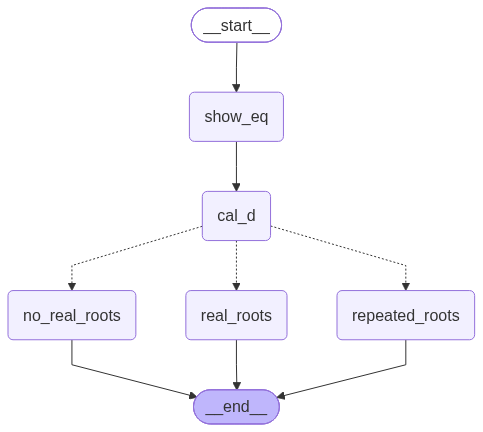

In [18]:
wf

In [19]:
initial_state = {
    'a': 4,
    'b': 2,
    'c': 4
}

wf.invoke(initial_state)

{'a': 4,
 'b': 2,
 'c': 4,
 'equation': '(4x2)+(2x)+(4)',
 'discriminant': -60,
 'result': 'No real roots.'}